# TRECHO SEM SAÍDA (Dead-end streets)

Juliana Lombard Souza

* Identifica os trechos que configuram ruas sem saída e trechos isolados (trechos com nós de início ou fim de apenas grau 1)

In [1]:
# Instalar as bibliotecas necessárias
!pip install geopandas networkx matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2 CONFIGURAÇÃO DE CAMINHOS

In [2]:
# Insira os caminhos completos para as suas pastas.
caminho_pasta_dados = r"c:/Users/Juliana/project/data" # renomeie aqui
caminho_pasta_saida = r"c:/Users/Juliana/project/output" # renomeie aqui

from pathlib import Path

# Converte as strings de texto para objetos Path
DATA_DIR = Path(caminho_pasta_dados)
OUTPUT_DIR = Path(caminho_pasta_saida)

# Validação para garantir que a pasta de dados existe
if not DATA_DIR.exists():
    raise FileNotFoundError(f"ERRO: A pasta de dados especificada não existe!\nVerifique o caminho: {DATA_DIR}")

# Cria a pasta de saída se ela não existir
if not OUTPUT_DIR.exists():
    print(f"A pasta de saída não existe. Criando-a em: {OUTPUT_DIR}")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
else:
    print(f"Pasta de saída encontrada em: {OUTPUT_DIR}")


# Define os caminhos para os arquivos
rede_shp = DATA_DIR / "rede_teste_lin.shp" # renomeie aqui
output_shp_path = OUTPUT_DIR / "rede_teste_ruas_sem_saida.shp" # renomeie aqui

print("Configuração de caminhos concluída com sucesso!")

Pasta de saída encontrada em: c:\Users\Juliana\project\output
Configuração de caminhos concluída com sucesso!


In [3]:
import geopandas as gpd
import networkx as nx

## 2 ANÁLISE E IDENTIFICAÇÃO

In [4]:
# 1. Carregar o shapefile
print(f"Carregando o arquivo de rede: {rede_shp}")
gdf_edges = gpd.read_file(rede_shp)

# 1.5. Limpeza dos Dados
# Remove todas as linhas que possuem geometria nula ou vazia
initial_count = len(gdf_edges)
gdf_edges = gdf_edges[gdf_edges.geometry.notnull()]
final_count = len(gdf_edges)
if initial_count != final_count:
    print(f"Limpeza de dados: {initial_count - final_count} feições com geometria nula foram removidas.")
print(f"Total de feições válidas para análise: {final_count}.")


# 2. Construir o grafo
print("\nConstruindo o grafo da rede...")
G = nx.Graph()
for _, line in gdf_edges.iterrows():
    # A verificação agora é redundante graças à limpeza, mas mantém o código seguro
    if line.geometry is not None and not line.geometry.is_empty:
        start_point = line.geometry.coords[0]
        end_point = line.geometry.coords[-1]
        G.add_edge(start_point, end_point)

# 3. Identificar nós de grau 1
print("Identificando nós de grau 1...")
degree_1_nodes = [node for node, degree in G.degree() if degree == 1]
print(f"Encontrados {len(degree_1_nodes)} nós de grau 1.")

# 4. Filtrar arestas
print("Filtrando os trechos de rua sem saída...")
degree_1_nodes_set = set(degree_1_nodes)
dead_end_edges = []

for _, edge in gdf_edges.iterrows():
    # Graças à limpeza, não precisamos mais verificar 'is None' aqui
    start_point = edge.geometry.coords[0]
    end_point = edge.geometry.coords[-1]
    
    if start_point in degree_1_nodes_set or end_point in degree_1_nodes_set:
        dead_end_edges.append(edge)

gdf_dead_ends = gpd.GeoDataFrame(dead_end_edges, crs=gdf_edges.crs)
print(f"Identificados {len(gdf_dead_ends)} trechos de ruas sem saída.")

# 5. Salvar o resultado
print(f"Salvando o resultado em: {output_shp_path}")
gdf_dead_ends.to_file(output_shp_path)

print("\n--- Análise concluída com sucesso! ---")

Carregando o arquivo de rede: c:\Users\Juliana\project\data\rede_teste_lin.shp
Total de feições válidas para análise: 13392.

Construindo o grafo da rede...
Identificando nós de grau 1...
Encontrados 2653 nós de grau 1.
Filtrando os trechos de rua sem saída...
Identificados 2641 trechos de ruas sem saída.
Salvando o resultado em: c:\Users\Juliana\project\output\rede_teste_ruas_sem_saida.shp

--- Análise concluída com sucesso! ---


## 3 VISUALIZAÇÃO

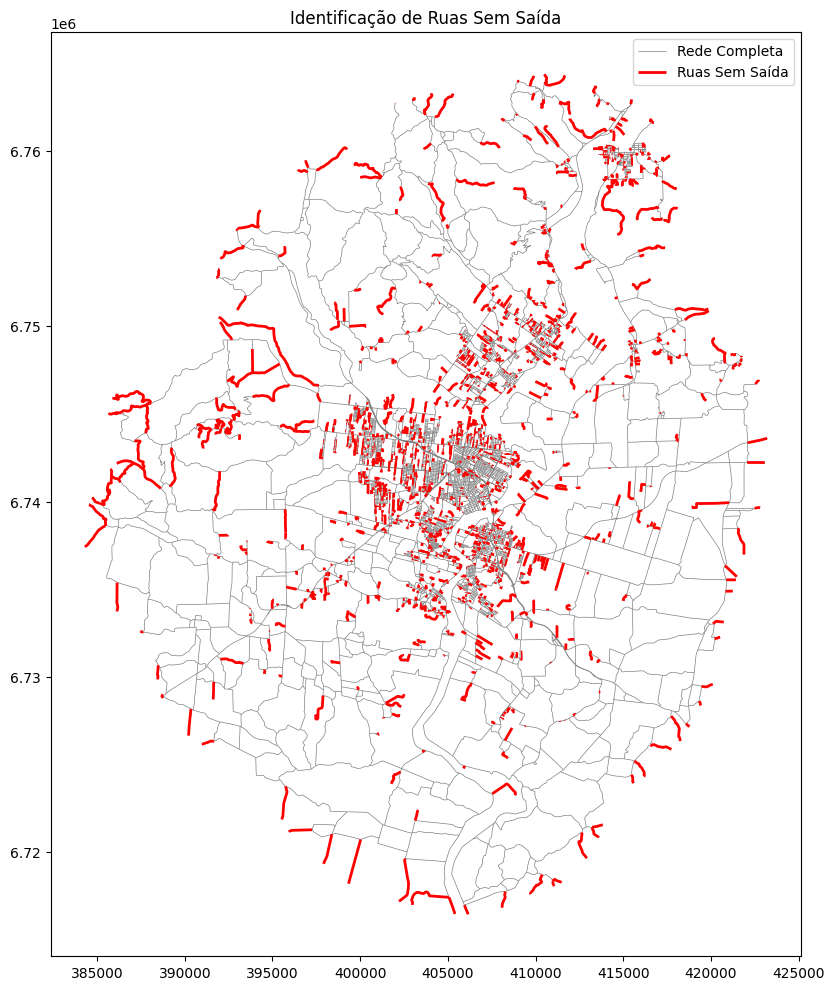

In [5]:
# Opcional: Visualizar o resultado
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plotar a rede original em cinza
gdf_edges.plot(ax=ax, color='gray', linewidth=0.5, label='Rede Completa')

# Plotar as ruas sem saída em vermelho
gdf_dead_ends.plot(ax=ax, color='red', linewidth=2, label='Ruas Sem Saída')

ax.set_title("Identificação de Ruas Sem Saída")
ax.legend()
plt.show()